# Steps to make t-test
 1. Write down the hypothesis and set an alpha value
 2. decide which test to use
 3. check the assumptions (see bonus)
 4. run t-test
 5. reporting the results
 6. conclusion

# Overview
1. independent t-test
    - two tails
    - one tail
2. dependent t-test
    - two tails
    - one tail
3. Bonus: assumptions before t-test
    - Independence
    - Population distributions are normal
    - Samples have equal variances
    - Data are measured at least at the interval level.

In [ ]:
import scipy.stats as stats
import numpy as np
import pandas as pd 

In [7]:
df = pd.read_csv("blood_pressure.csv")

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   patient         120 non-null    int64
 1   sex             120 non-null    str  
 2   agegrp          120 non-null    str  
 3   blood_pressure  120 non-null    int64
dtypes: int64(2), str(2)
memory usage: 3.9 KB


## Formulation of H0 & H1
We can formulate our H0 and H1 in different ways. For now we will use a two-sided hypothesis:
$\underline{H_0}: \mu_1 = \mu_2 \longrightarrow there \ is \ \underline{no} \ difference \ between \ the \ groups$
$\underline{H_1}: \mu_1 \ne \mu_2 \longrightarrow there \ is \ \underline{a} \ difference \ between \ the \ groups$


## Critical t value

The critical t-value is determined by the degrees of freedom [ $df$ ] and the alpha [ $\alpha$ ] value

- $df = n_1 + n_2 - 2$
- $\alpha$ is set to 0.05 (our choice)

Where:

- $n_1$ = sample size for group 1 (men)
- $n_2$ = sample size for group 2 (women)

Look up critical t-value in a [t-table](https://www.sjsu.edu/faculty/gerstman/StatPrimer/t-table.pdf)

In [9]:
x1 = df[df["sex"] == "Male"]["blood_pressure"]

In [10]:
x2 = df[df["sex"] == "Female"]["blood_pressure"]


In [11]:
n1 = len(x1)
n2 = len(x2)

In [12]:
#degrees of freedom 
dof = n1 + n2 - 2

In [13]:
# going to the table in the mkdow file and find closest to dof and the value that we want 
critical_t = 1.984

### Independent t-test formula

$$t = \frac{\bar{x}1 - \bar{x}2}{\sqrt{\frac{S1^2}{n1} + \frac{S2^2}{n2}}}$$

#### Let's calculate t
$numerator = \bar{x}1 - \bar{x}2$[10:39 AM]$denominator = \sqrt{\frac{S1^2}{n1} + \frac{S2^2}{n2}}$

In [14]:
numerator = x1.mean()-x2.mean()
numerator

np.float64(8.316666666666691)

In [15]:
denominator = np.sqrt((x1.std()**2)/n1+ ((x2.std())**2)/n2)
denominator

np.float64(2.4841067312726417)

In [16]:
t = numerator / denominator

In [17]:
t > critical_t

np.True_

In [18]:
# using scipy
stats.ttest_ind(x1,x2)

TtestResult(statistic=np.float64(3.3479506182111387), pvalue=np.float64(0.0010930222986154292), df=np.float64(118.0))

In [19]:
#import researchpy as rp

In [20]:
import seaborn as sns 
import matplotlib.pyplot as plt


(140.0, 170.0)

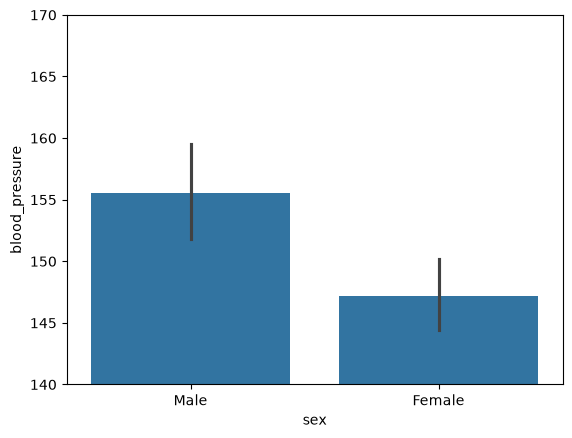

In [21]:
sns.barplot(data=df, x = "sex", y = "blood_pressure")
plt.ylim(140,170)

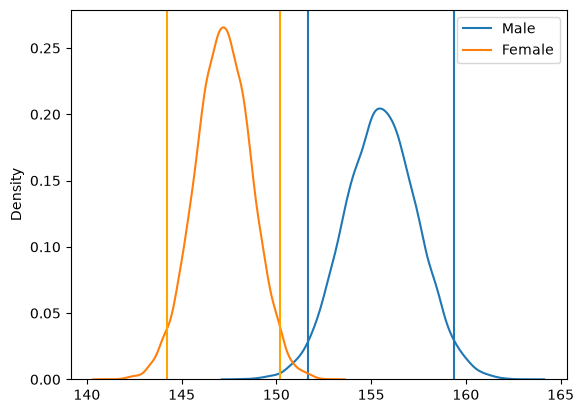

In [22]:
# visualization of the 95 % confidence interval

sns.kdeplot(np.random.normal(loc = x1.mean(), scale = x1.sem(), size = 10000), label = "Male")
plt.axvline(stats.norm(loc = x1.mean(), scale = x1.sem()).ppf(0.025))
plt.axvline(stats.norm(loc = x1.mean(), scale = x1.sem()).ppf(0.975))

sns.kdeplot(np.random.normal(loc = x2.mean(), scale = x2.sem(), size = 10000), label = "Female")
plt.axvline(stats.norm(loc = x2.mean(), scale = x2.sem()).ppf(0.025), color = "orange")
plt.axvline(stats.norm(loc = x2.mean(), scale = x2.sem()).ppf(0.975), color = "orange")
plt.legend()


## If men has a higher blood pressure than women?
Less than (One-tail):
- $H_0: \mu_1 \le \mu_2 \ men \ has \ a \ lower \ or \ equal \ mean \ of \ blood \ pressure \ than \ women$
- $H_1: \mu_1 > \mu_2 \ men \ has \ a \ higher \ mean \ of \ blood \ pressure \ than \ women $

In [23]:
stats.ttest_ind(x1,x2, alternative = "greater")

TtestResult(statistic=np.float64(3.3479506182111387), pvalue=np.float64(0.0005465111493077146), df=np.float64(118.0))

# Dependant t-test

In [24]:
df = pd.read_csv("before_after.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'before_after.csv'

### Step 1: Hypothesis and alpha
Three ways to make hypothesis:
1. There is a difference of blood pressure between before and after treatment (two tails) <br>
    - $H_0: \mu_1 = \mu_2 \longrightarrow there \ is \ \underline{no} \ difference \ of \ mean \ in \ blood \ pressure \ before \ and \ after \ treatment \ in \ men $
    - $H_1: \mu_1 \ne \mu_2 \longrightarrow there \ is \ \underline{a} \ difference \ of  mean \ in \ blood \ pressure \ before \ and \ after \ treatment \ in \ men $
    <br>
    <br>
2. if blood pressure before treatment  is __higher__ than after (one tail) <br>
Greater than :
    - $H_0: \mu_1 \le \mu_2 \longrightarrow Blood \ pressure \ before \ treatment \ is \ \underline{lower} \ or \ \underline{equal} \ to \ after \ treatment $
    - $H_1: \mu_1 > \mu_2 \longrightarrow Blood \ pressure \ before \ treatment \ is \ \underline{higher} \ than \ after \ treatment $
<br>
<br>
3. If blood pressure before treatment  is __lower__ than after (one tail) <br>
    Less than :
    - $H_0: \mu_1 \ge \mu_2 \longrightarrow Blood \ pressure \ before \ treatment \ is  \ \underline{higher} \ or \ \underline{equal} \ to \ after \ treatment $
    - $H_1: \mu_1 < \mu_2 \longrightarrow Blood \ pressure \ before \ treatment \ is  \ \underline{lower} \ than \ after \ treatment $

<br>
alpha = 0.05


### dependent t-test formula
$$ t = \frac{m}{s \ / \ \sqrt{n}}$$
<br>
1. calculate d: the differences between all pairs <br>
m : mean of d <br>
s : standard deviation of d <br>
n : number of pairs <br>


In [ ]:
df = df.loc[df.sex == "Male"]



In [ ]:
dof = len(df) - 1 
dof

59

In [ ]:
t_critical = 1.671

In [ ]:
df["difference"] = df["bp_before"] - df["bp_after"]
df

,patient,sex,agegrp,bp_before,bp_after,difference
0,1,Male,30-45,143,153,-10
1,2,Male,30-45,163,170,-7
2,3,Male,30-45,153,168,-15
3,4,Male,30-45,153,142,11
4,5,Male,30-45,146,141,5
5,6,Male,30-45,150,147,3
6,7,Male,30-45,148,133,15
7,8,Male,30-45,153,141,12
8,9,Male,30-45,153,131,22
9,10,Male,30-45,158,125,33


In [ ]:
t = df["difference"].mean() / (df["difference"].std()) / np.sqrt(len(df))
t

np.float64(0.025718993316949573)

In [ ]:
t > critical_t

np.False_

In [ ]:
men_before = df["bp_before"]
men_after =  df["bp_after"]

In [ ]:
stats.ttest_rel(men_before, men_after, alternative = "greater")

TtestResult(statistic=np.float64(1.5431395990169743), pvalue=np.float64(0.06407199886386135), df=np.int64(59))

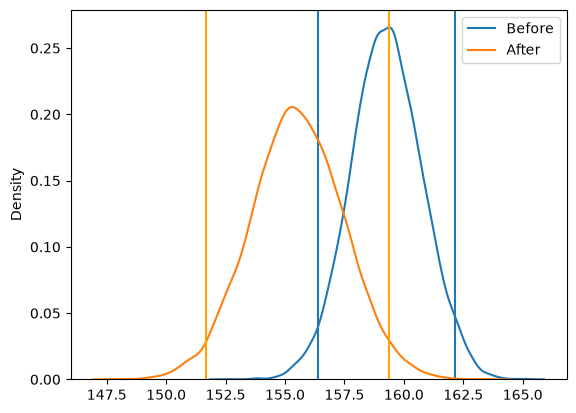

In [ ]:
sns.kdeplot(np.random.normal(loc = men_before.mean(), scale = men_before.sem(), size = 10000), label = "Before")
plt.axvline(stats.norm(loc = men_before.mean(), scale = men_before.sem()).ppf(0.025))
plt.axvline(stats.norm(loc = men_before.mean(), scale = men_before.sem()).ppf(0.975))

sns.kdeplot(np.random.normal(loc = men_after.mean(), scale = men_after.sem(), size = 10000), label = "After")
plt.axvline(stats.norm(loc = men_after.mean(), scale = men_after.sem()).ppf(0.025), color = "orange")
plt.axvline(stats.norm(loc = men_after.mean(), scale = men_after.sem()).ppf(0.975), color = "orange")
plt.legend()